# Frequency Domain Feature Extraction – FFT Ring Spectrum & DoG Wavelet

Notebook này trích xuất đặc trưng từ **miền tần số** thay vì miền không gian như notebook 02.

Hai phương pháp chính:
1. **FFT 2D Ring Spectrum**: Phân tích năng lượng theo vòng bán kính trên phổ Fourier 2D.
2. **DoG Wavelet (Difference of Gaussians)**: Xấp xỉ LoG đa thang đo để phát hiện blob/ngưng kết.

Cả hai đều áp dụng trên từng mask (anti_a_blue, anti_b_yellow, blood_red, foreground, reaction_candidate).

**Output:** `processed/frequency_domain/frequency_domain_features.csv`


## 0. Setup & Imports

In [1]:
from pathlib import Path
import json, re, math
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift
from scipy.ndimage import gaussian_filter

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

SPLITS = ["train", "valid", "test"]

if IN_COLAB:
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/Blood Group Detection.coco")
else:
    ROOT = Path.cwd()

if not all((ROOT / s / "_annotations.coco.json").exists() for s in SPLITS):
    raise FileNotFoundError("COCO dataset not found. Edit ROOT.")

OUTPUT_DIR = ROOT / "processed" / "frequency_domain"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FFT_PATCH_SIZE = 64
FFT_N_BANDS    = 8
DOG_SCALES     = [(1.0, 1.6), (2.0, 3.2), (4.0, 6.4), (8.0, 12.8)]

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)
ROOT, OUTPUT_DIR

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(PosixPath('/content/drive/MyDrive/Blood Group Detection.coco'),
 PosixPath('/content/drive/MyDrive/Blood Group Detection.coco/processed/frequency_domain'))

## 1. Load Image List

In [2]:
def parse_blood_group(name):
    m = re.match(r"^(AB|A|B|O)[+-]", name)
    return m.group(0) if m else "UNKNOWN"

def load_images_table():
    rows = []
    for split in SPLITS:
        path = ROOT / split / "_annotations.coco.json"
        with path.open("r", encoding="utf-8") as f:
            data = json.load(f)
        for img in data["images"]:
            orig = img.get("extra", {}).get("name", img["file_name"])
            bg = parse_blood_group(orig)
            rows.append({
                "split": split, "image_id": img["id"],
                "file_name": img["file_name"], "original_name": orig,
                "blood_group": bg,
                "abo": bg[:-1] if bg != "UNKNOWN" else "UNKNOWN",
                "rh": bg[-1] if bg != "UNKNOWN" else "UNKNOWN",
                "width": img["width"], "height": img["height"],
                "image_path": str(ROOT / split / img["file_name"]),
            })
    return pd.DataFrame(rows)

images_df = load_images_table()
print(f"Loaded {len(images_df)} images")
images_df.head()

Loaded 2072 images


,split,image_id,file_name,original_name,blood_group,abo,rh,width,height,image_path
0,train,0,B- (8)_jpg.rf.Y4gSPakmKnxXtqrN20gd.jpg,B- (8).jpg,B-,B,-,2644,868,/content/drive/MyDrive/Blood Group Detection.c...
1,train,1,AB- (59)_jpg.rf.XqNFkV6f7JNjc2LlN7za.jpg,AB- (59).jpg,AB-,AB,-,991,302,/content/drive/MyDrive/Blood Group Detection.c...
2,train,2,A+ (7)_jpg.rf.YMFIioqVqZGqD5EMeCtF.jpg,A+ (7).jpg,A+,A,+,1995,607,/content/drive/MyDrive/Blood Group Detection.c...
3,train,3,A+ (14)_jpg.rf.sSksp3LBJpQi1ohZIjYl.jpg,A+ (14).jpg,A+,A,+,2538,768,/content/drive/MyDrive/Blood Group Detection.c...
4,train,4,B- (95)_jpg.rf.Y9dEJiYDftKo36eOzT7I.jpg,B- (95).jpg,B-,B,-,1019,341,/content/drive/MyDrive/Blood Group Detection.c...


## 2. Color Segmentation (giống notebook 02)

In [3]:
def read_rgb(path, max_side=1200):
    bgr = cv2.imread(path)
    if bgr is None:
        raise FileNotFoundError(path)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    h, w = rgb.shape[:2]
    scale = max(h, w) / max_side
    if scale > 1:
        rgb = cv2.resize(rgb, (int(w/scale), int(h/scale)), interpolation=cv2.INTER_AREA)
    return rgb

def clean_mask(mask, kernel_size=5, min_area=80):
    mask = mask.astype(np.uint8)
    k = np.ones((kernel_size, kernel_size), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    out = np.zeros_like(mask)
    for lbl in range(1, num_labels):
        if stats[lbl, cv2.CC_STAT_AREA] >= min_area:
            out[labels == lbl] = 1
    return out.astype(bool)

def segment_image(rgb):
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    h, s, v = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]
    masks = {
        "anti_a_blue":   clean_mask((h>=80)&(h<=135)&(s>=35)&(v>=35), 5, 120),
        "anti_b_yellow": clean_mask((h>=15)&(h<=45) &(s>=35)&(v>=45), 5, 120),
        "blood_red":     clean_mask(((h<=12)|(h>=165))&(s>=30)&(v>=30), 5, 120),
        "foreground":    clean_mask(((s>=38)&(v>=30)&(v<=250))|((s>=18)&(v<=150)), 5, 200),
    }
    masks["reaction_candidate"] = masks["foreground"] & (
        masks["blood_red"] | masks["anti_a_blue"] | masks["anti_b_yellow"])
    return masks

## 3. Feature Extraction Functions

### 3.1. FFT 2D Ring Spectrum

Phổ Fourier 2D được tính trên patch (64×64) cắt từ bounding-box của mask. Năng lượng được đo trên 8 vòng bán kính:
- **Band 0-1** (tần thấp): cấu trúc lớn, màu đồng đều.
- **Band 6-7** (tần cao): cạnh sắc, hạt nhỏ, ngưng kết.

Kèm theo: spectral centroid, spectral spread, dc_ratio, high_ratio.


In [4]:
def _patch_from_mask(gray, mask):
    """Cắt bounding-box của mask và resize về 64x64."""
    ys, xs = np.where(mask)
    if ys.size == 0:
        return None
    patch = gray[ys.min():ys.max()+1, xs.min():xs.max()+1].astype(np.float32)
    return cv2.resize(patch, (FFT_PATCH_SIZE, FFT_PATCH_SIZE), interpolation=cv2.INTER_AREA)

def fft_ring_features(gray, mask, prefix):
    n = FFT_N_BANDS
    empty = {f"{prefix}_fft_band{i}_energy": 0.0 for i in range(n)}
    empty.update({f"{prefix}_fft_band{i}_ratio": 0.0 for i in range(n)})
    for k in ["dc_ratio", "high_ratio", "spectral_centroid", "spectral_spread"]:
        empty[f"{prefix}_fft_{k}"] = 0.0

    patch = _patch_from_mask(gray, mask)
    if patch is None:
        return empty

    mag = np.abs(fftshift(fft2(patch)))
    h, w = mag.shape
    cy, cx = h//2, w//2
    yi, xi = np.ogrid[:h, :w]
    r_map = np.sqrt((xi-cx)**2 + (yi-cy)**2)
    max_r = min(cx, cy)

    band_e = []
    for i in range(n):
        ring = mag[(r_map >= i*max_r/n) & (r_map < (i+1)*max_r/n)]
        band_e.append(float(ring.mean()) if ring.size else 0.0)

    total = sum(band_e) + 1e-9
    feats = {f"{prefix}_fft_band{i}_energy": e for i, e in enumerate(band_e)}
    feats.update({f"{prefix}_fft_band{i}_ratio": e/total for i, e in enumerate(band_e)})
    feats[f"{prefix}_fft_dc_ratio"] = (band_e[0]+band_e[1]) / total
    feats[f"{prefix}_fft_high_ratio"] = sum(band_e[n//2:]) / total

    rf, mf = r_map.flatten(), mag.flatten()
    ws = mf.sum() + 1e-9
    c = float(np.dot(rf, mf) / ws)
    feats[f"{prefix}_fft_spectral_centroid"] = c
    feats[f"{prefix}_fft_spectral_spread"] = float(np.sqrt(np.dot((rf-c)**2, mf) / ws))
    return feats

### 3.2. DoG Wavelet Multi-Scale Features

4 thang đo σ: (1.0, 1.6), (2.0, 3.2), (4.0, 6.4), (8.0, 12.8)

Mỗi thang đo cho: mean, std, energy, peak_ratio (|resp| > 1σ), neg_ratio (phần âm).
Thêm cross-scale ratio: energy thang nhỏ / energy thang lớn.


In [5]:
def dog_response(gray_f, sf, sc):
    return gaussian_filter(gray_f, sf) - gaussian_filter(gray_f, sc)

def dog_wavelet_features(gray, mask, prefix):
    feats = {}
    gray_f = gray.astype(np.float32)
    energies = []
    for sf, sc in DOG_SCALES:
        tag = f"s{int(sf*10):03d}"
        resp = dog_response(gray_f, sf, sc)
        region = resp[mask] if mask.any() else np.array([])
        if region.size == 0:
            feats[f"{prefix}_dog_{tag}_mean"] = 0.0
            feats[f"{prefix}_dog_{tag}_std"]  = 0.0
            feats[f"{prefix}_dog_{tag}_energy"] = 0.0
            feats[f"{prefix}_dog_{tag}_peak_ratio"] = 0.0
            feats[f"{prefix}_dog_{tag}_neg_ratio"]  = 0.0
            energies.append(0.0)
        else:
            std = float(region.std()) + 1e-9
            e   = float(np.mean(region**2))
            feats[f"{prefix}_dog_{tag}_mean"]       = float(region.mean())
            feats[f"{prefix}_dog_{tag}_std"]        = std
            feats[f"{prefix}_dog_{tag}_energy"]     = e
            feats[f"{prefix}_dog_{tag}_peak_ratio"] = float((np.abs(region) > std).mean())
            feats[f"{prefix}_dog_{tag}_neg_ratio"]  = float((region < 0).mean())
            energies.append(e)
    feats[f"{prefix}_dog_fine_coarse_ratio"] = (energies[0]+1e-9) / (energies[-1]+1e-9)
    return feats

## 4. Tổng hợp feature cho một ảnh

In [6]:
MASK_NAMES = ["anti_a_blue", "anti_b_yellow", "blood_red", "foreground", "reaction_candidate"]

def extract_frequency_features(rgb):
    gray  = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    masks = segment_image(rgb)
    feats = {"resized_width": rgb.shape[1], "resized_height": rgb.shape[0]}
    for mn in MASK_NAMES:
        mask = masks.get(mn, np.zeros(gray.shape, dtype=bool))
        feats[f"{mn}_mask_present"] = int(mask.any())
        feats.update(fft_ring_features(gray, mask, mn))
        feats.update(dog_wavelet_features(gray, mask, mn))
    return feats

# Smoke-test
dummy = np.random.randint(0, 255, (300, 400, 3), dtype=np.uint8)
dummy_feats = extract_frequency_features(dummy)
print(f"Feature count per image: {len(dummy_feats)}")
print(list(dummy_feats.keys())[:15])

Feature count per image: 212
['resized_width', 'resized_height', 'anti_a_blue_mask_present', 'anti_a_blue_fft_band0_energy', 'anti_a_blue_fft_band1_energy', 'anti_a_blue_fft_band2_energy', 'anti_a_blue_fft_band3_energy', 'anti_a_blue_fft_band4_energy', 'anti_a_blue_fft_band5_energy', 'anti_a_blue_fft_band6_energy', 'anti_a_blue_fft_band7_energy', 'anti_a_blue_fft_band0_ratio', 'anti_a_blue_fft_band1_ratio', 'anti_a_blue_fft_band2_ratio', 'anti_a_blue_fft_band3_ratio']


## 5. Visualization

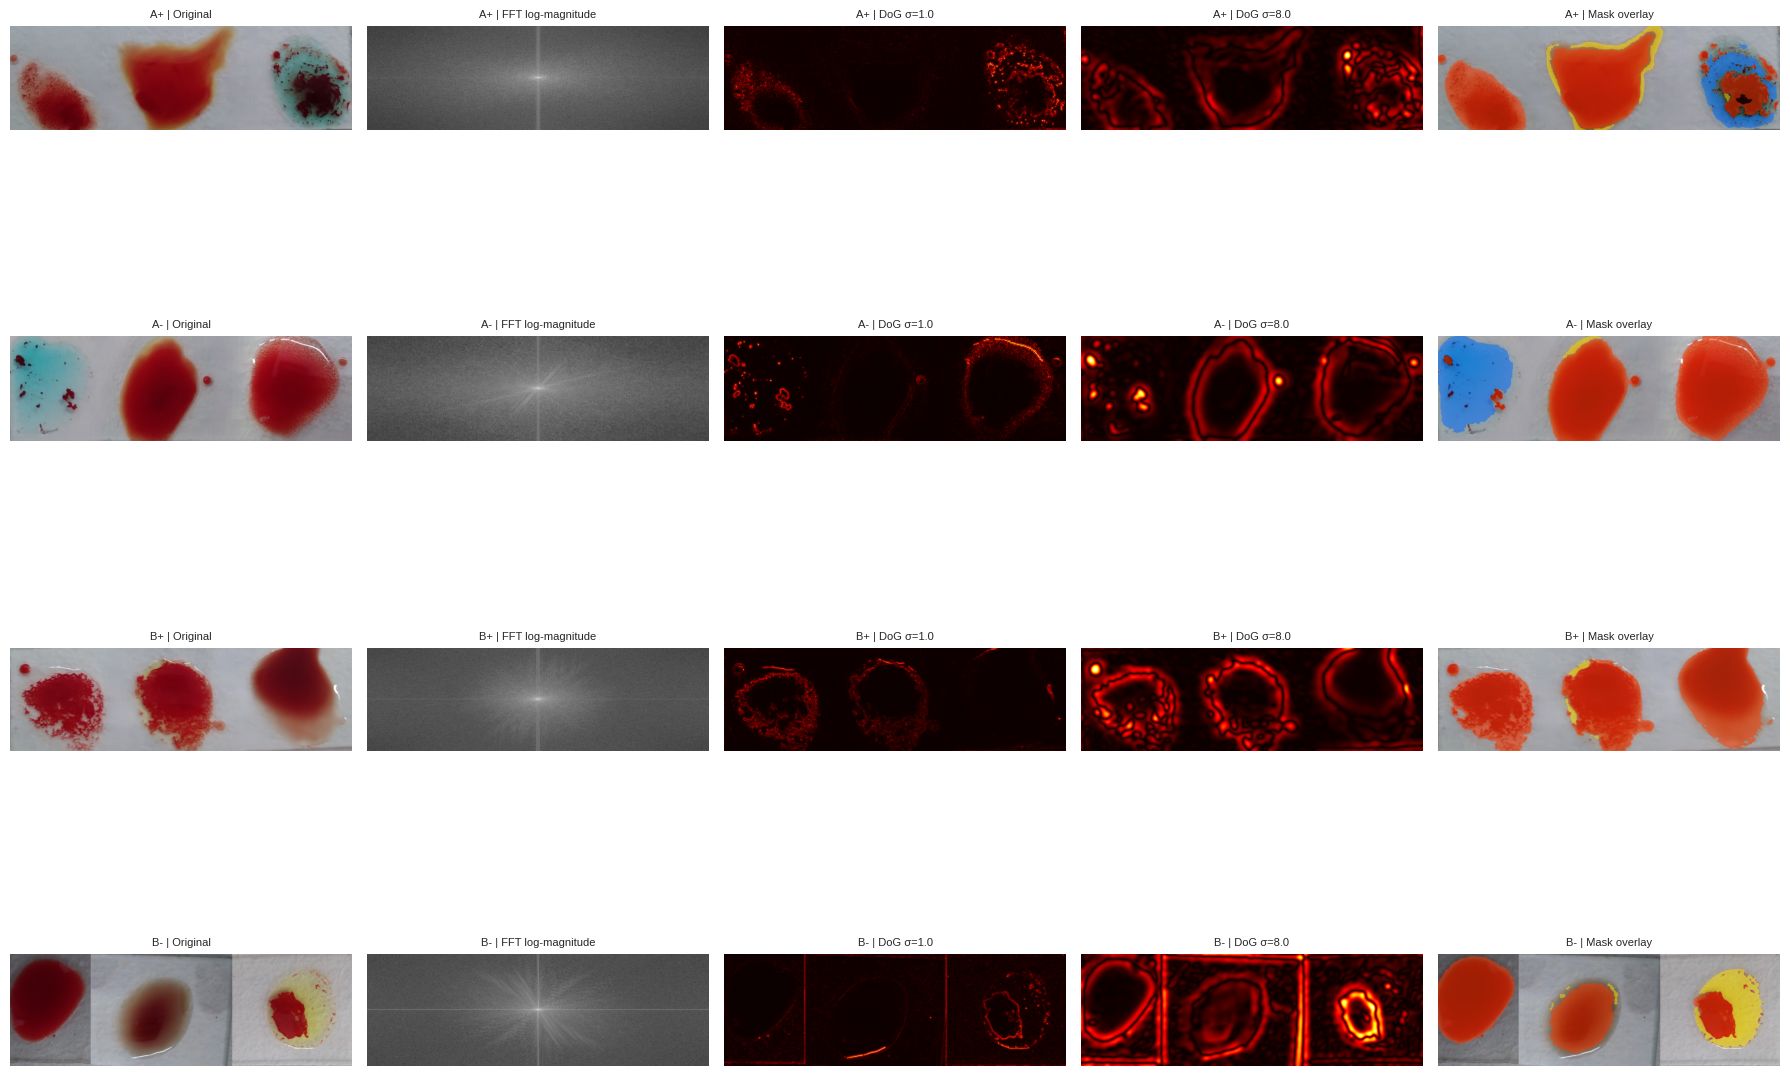

In [7]:
def pick_one_per_group(df):
    order = ["A+","A-","B+","B-","AB+","AB-","O+","O-"]
    rows  = [df[df["blood_group"]==lbl].iloc[0]
             for lbl in order if not df[df["blood_group"]==lbl].empty]
    return pd.DataFrame(rows)

samples = pick_one_per_group(images_df)

def visualize_freq(samples, n=4):
    n = min(n, len(samples))
    fig, axes = plt.subplots(n, 5, figsize=(18, 3.5*n))
    if n == 1: axes = np.array([axes])
    for r, (_, row) in enumerate(samples.head(n).iterrows()):
        rgb  = read_rgb(row["image_path"])
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
        masks = segment_image(rgb)
        mag  = np.log1p(np.abs(fftshift(fft2(gray))))
        resp_fine   = dog_response(gray, DOG_SCALES[0][0], DOG_SCALES[0][1])
        resp_coarse = dog_response(gray, DOG_SCALES[-1][0], DOG_SCALES[-1][1])
        overlay = rgb.copy()
        for col, mn in zip([(0,100,255),(255,220,0),(255,60,0)],
                           ["anti_a_blue","anti_b_yellow","blood_red"]):
            overlay[masks[mn]] = (0.5*overlay[masks[mn]] + 0.5*np.array(col)).astype(np.uint8)
        for c, (img, ttl, cm) in enumerate([
            (rgb, "Original", None),
            (mag, "FFT log-magnitude", "gray"),
            (np.abs(resp_fine),   "DoG σ=1.0", "hot"),
            (np.abs(resp_coarse), "DoG σ=8.0", "hot"),
            (overlay, "Mask overlay", None),
        ]):
            axes[r,c].imshow(img, cmap=cm)
            axes[r,c].set_title(f"{row['blood_group']} | {ttl}", fontsize=8)
            axes[r,c].axis("off")
    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR/"frequency_domain_preview.png"), dpi=100, bbox_inches="tight")
    plt.show()

visualize_freq(samples)

## 6. Trích feature toàn bộ dataset

In [8]:
rows, errors = [], []
for idx, row in images_df.iterrows():
    try:
        rgb   = read_rgb(row["image_path"])
        feats = extract_frequency_features(rgb)
        feats.update({k: row[k] for k in ["split","file_name","blood_group","abo","rh"]})
        rows.append(feats)
    except Exception as e:
        errors.append({"file": row["file_name"], "error": str(e)})
    if (idx+1) % 50 == 0:
        print(f"Processed {idx+1}/{len(images_df)}")

print(f"Done: {len(rows)} ok, {len(errors)} errors")
if errors: print("Errors:", errors[:3])

Processed 50/2072
Processed 100/2072
Processed 150/2072
Processed 200/2072
Processed 250/2072
Processed 300/2072
Processed 350/2072
Processed 400/2072
Processed 450/2072
Processed 500/2072
Processed 550/2072
Processed 600/2072
Processed 650/2072
Processed 700/2072
Processed 750/2072
Processed 800/2072
Processed 850/2072
Processed 900/2072
Processed 950/2072
Processed 1000/2072
Processed 1050/2072
Processed 1100/2072
Processed 1150/2072
Processed 1200/2072
Processed 1250/2072
Processed 1300/2072
Processed 1350/2072
Processed 1400/2072
Processed 1450/2072
Processed 1500/2072
Processed 1550/2072
Processed 1600/2072
Processed 1650/2072
Processed 1700/2072
Processed 1750/2072
Processed 1800/2072
Processed 1850/2072
Processed 1900/2072
Processed 1950/2072
Processed 2000/2072
Processed 2050/2072
Done: 2072 ok, 0 errors


In [9]:
freq_df = pd.DataFrame(rows)
meta_cols = ["split","file_name","blood_group","abo","rh","resized_width","resized_height"]
other_cols = [c for c in freq_df.columns if c not in meta_cols]
freq_df = freq_df[meta_cols + other_cols].fillna(0.0)

out = OUTPUT_DIR / "frequency_domain_features.csv"
freq_df.to_csv(out, index=False)
print(f"Saved: {out}")
print(f"Shape: {freq_df.shape}")
freq_df.head()

Saved: /content/drive/MyDrive/Blood Group Detection.coco/processed/frequency_domain/frequency_domain_features.csv
Shape: (2072, 217)


,split,file_name,blood_group,abo,rh,resized_width,resized_height,anti_a_blue_mask_present,anti_a_blue_fft_band0_energy,anti_a_blue_fft_band1_energy,anti_a_blue_fft_band2_energy,anti_a_blue_fft_band3_energy,anti_a_blue_fft_band4_energy,anti_a_blue_fft_band5_energy,anti_a_blue_fft_band6_energy,anti_a_blue_fft_band7_energy,anti_a_blue_fft_band0_ratio,anti_a_blue_fft_band1_ratio,anti_a_blue_fft_band2_ratio,anti_a_blue_fft_band3_ratio,anti_a_blue_fft_band4_ratio,anti_a_blue_fft_band5_ratio,anti_a_blue_fft_band6_ratio,anti_a_blue_fft_band7_ratio,anti_a_blue_fft_dc_ratio,anti_a_blue_fft_high_ratio,anti_a_blue_fft_spectral_centroid,anti_a_blue_fft_spectral_spread,anti_a_blue_dog_s010_mean,anti_a_blue_dog_s010_std,anti_a_blue_dog_s010_energy,anti_a_blue_dog_s010_peak_ratio,anti_a_blue_dog_s010_neg_ratio,anti_a_blue_dog_s020_mean,anti_a_blue_dog_s020_std,anti_a_blue_dog_s020_energy,anti_a_blue_dog_s020_peak_ratio,anti_a_blue_dog_s020_neg_ratio,anti_a_blue_dog_s040_mean,anti_a_blue_dog_s040_std,anti_a_blue_dog_s040_energy,anti_a_blue_dog_s040_peak_ratio,anti_a_blue_dog_s040_neg_ratio,anti_a_blue_dog_s080_mean,anti_a_blue_dog_s080_std,anti_a_blue_dog_s080_energy,anti_a_blue_dog_s080_peak_ratio,anti_a_blue_dog_s080_neg_ratio,anti_a_blue_dog_fine_coarse_ratio,anti_b_yellow_mask_present,anti_b_yellow_fft_band0_energy,anti_b_yellow_fft_band1_energy,anti_b_yellow_fft_band2_energy,anti_b_yellow_fft_band3_energy,anti_b_yellow_fft_band4_energy,anti_b_yellow_fft_band5_energy,anti_b_yellow_fft_band6_energy,anti_b_yellow_fft_band7_energy,anti_b_yellow_fft_band0_ratio,anti_b_yellow_fft_band1_ratio,...,foreground_dog_s010_peak_ratio,foreground_dog_s010_neg_ratio,foreground_dog_s020_mean,foreground_dog_s020_std,foreground_dog_s020_energy,foreground_dog_s020_peak_ratio,foreground_dog_s020_neg_ratio,foreground_dog_s040_mean,foreground_dog_s040_std,foreground_dog_s040_energy,foreground_dog_s040_peak_ratio,foreground_dog_s040_neg_ratio,foreground_dog_s080_mean,foreground_dog_s080_std,foreground_dog_s080_energy,foreground_dog_s080_peak_ratio,foreground_dog_s080_neg_ratio,foreground_dog_fine_coarse_ratio,reaction_candidate_mask_present,reaction_candidate_fft_band0_energy,reaction_candidate_fft_band1_energy,reaction_candidate_fft_band2_energy,reaction_candidate_fft_band3_energy,reaction_candidate_fft_band4_energy,reaction_candidate_fft_band5_energy,reaction_candidate_fft_band6_energy,reaction_candidate_fft_band7_energy,reaction_candidate_fft_band0_ratio,reaction_candidate_fft_band1_ratio,reaction_candidate_fft_band2_ratio,reaction_candidate_fft_band3_ratio,reaction_candidate_fft_band4_ratio,reaction_candidate_fft_band5_ratio,reaction_candidate_fft_band6_ratio,reaction_candidate_fft_band7_ratio,reaction_candidate_fft_dc_ratio,reaction_candidate_fft_high_ratio,reaction_candidate_fft_spectral_centroid,reaction_candidate_fft_spectral_spread,reaction_candidate_dog_s010_mean,reaction_candidate_dog_s010_std,reaction_candidate_dog_s010_energy,reaction_candidate_dog_s010_peak_ratio,reaction_candidate_dog_s010_neg_ratio,reaction_candidate_dog_s020_mean,reaction_candidate_dog_s020_std,reaction_candidate_dog_s020_energy,reaction_candidate_dog_s020_peak_ratio,reaction_candidate_dog_s020_neg_ratio,reaction_candidate_dog_s040_mean,reaction_candidate_dog_s040_std,reaction_candidate_dog_s040_energy,reaction_candidate_dog_s040_peak_ratio,reaction_candidate_dog_s040_neg_ratio,reaction_candidate_dog_s080_mean,reaction_candidate_dog_s080_std,reaction_candidate_dog_s080_energy,reaction_candidate_dog_s080_peak_ratio,reaction_candidate_dog_s080_neg_ratio,reaction_candidate_dog_fine_coarse_ratio
0,train,B- (8)_jpg.rf.Y4gSPakmKnxXtqrN20gd.jpg,B-,B,-,1200,393,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000

## 7. Kiểm tra phân bố feature theo nhóm máu

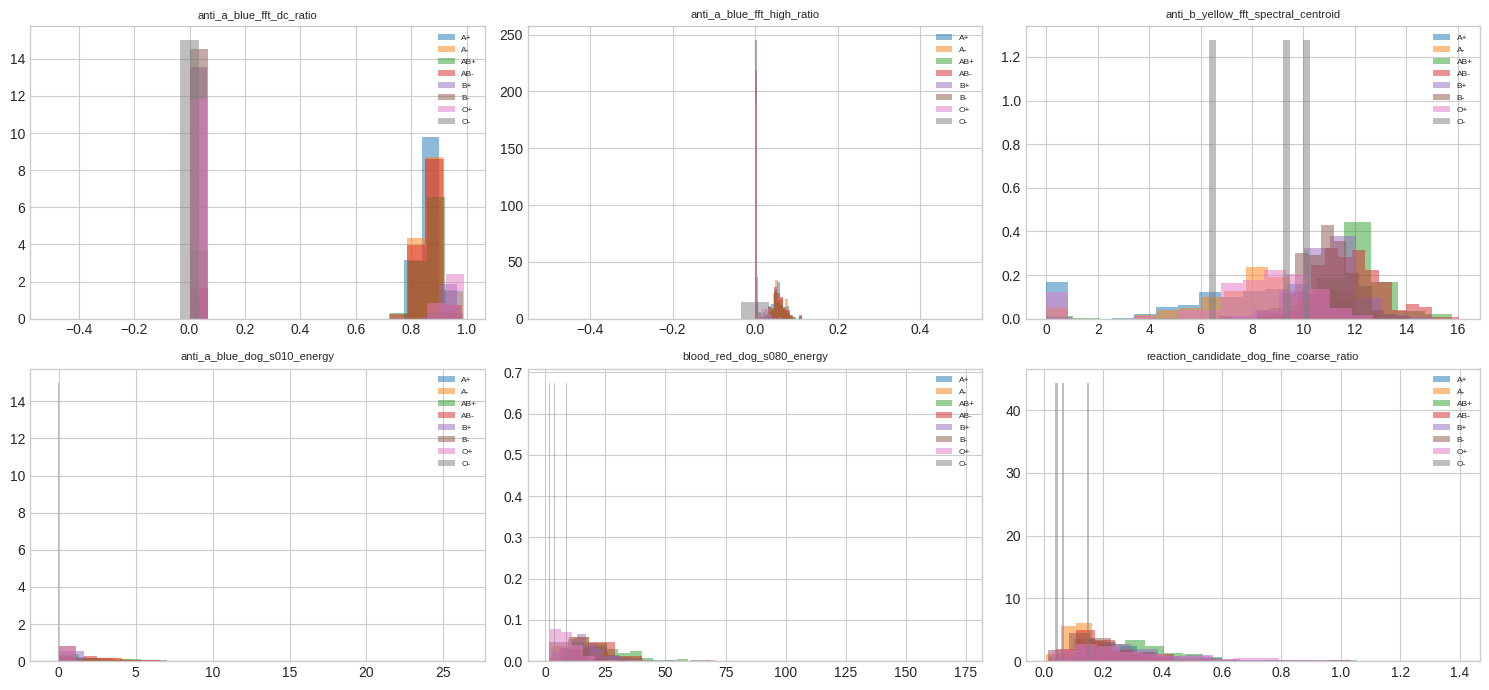

In [10]:
INSPECT = [
    "anti_a_blue_fft_dc_ratio",
    "anti_a_blue_fft_high_ratio",
    "anti_b_yellow_fft_spectral_centroid",
    "anti_a_blue_dog_s010_energy",
    "blood_red_dog_s080_energy",
    "reaction_candidate_dog_fine_coarse_ratio",
]
available = [f for f in INSPECT if f in freq_df.columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, feat in zip(axes.flatten(), available):
    for grp, gdf in freq_df.groupby("blood_group"):
        ax.hist(gdf[feat].dropna(), bins=15, alpha=0.5, label=grp, density=True)
    ax.set_title(feat, fontsize=8); ax.legend(fontsize=6)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR/"frequency_feature_distributions.png"), dpi=100, bbox_inches="tight")
plt.show()

## 8. Ghi chú

- **FFT Ring Spectrum**: 8 vòng × 4 features (energy, ratio, dc_ratio, high_ratio, spectral_centroid, spectral_spread) × 5 masks = ~80 features tần số cơ bản.
- **DoG Wavelet**: 4 thang đo × 5 features + 1 cross-scale ratio × 5 masks = ~105 features wavelet.
- Tổng ~185 features/ảnh (không tính metadata).

File này có thể dùng độc lập hoặc merge với `color_segmentation_features.csv` để mở rộng feature space.
